# FITS Image Visualization with Jupyter Notebook

### ImViz using Jdavis

In [6]:
from jdaviz import Imviz

In [9]:
imviz = Imviz()
imviz.show()
imviz.load_data('/Users/sshapiro/Downloads/JadenData/Stacked_11_M 44_10.0s_IRCUT_20250427-210832.fit', data_label='356w') #Replace with your own file

Application(config='imviz', docs_link='https://jdaviz.readthedocs.io/en/v4.2.2/imviz/index.html', events=['cal…

ValueError: [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x34197d160>] does not have any FITS image

#### There is another method for visualizing the file that lets you do a lot more with the data

In [7]:
from astropy.io import fits

In [12]:
hdul = fits.open('/Users/sshapiro/Downloads/JadenData/Stacked_15_M 42_10.0s_LP_20250427-212350.fit') #Replace with your own data file
hdul.info() #This will tell you the information available within your file

Filename: /Users/sshapiro/Downloads/JadenData/Stacked_15_M 42_10.0s_LP_20250427-212350.fit
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      82   (1080, 1920, 3)   int16 (rescales to uint16)   


In [15]:
f356w = fits.open('/Users/sshapiro/Desktop/356w DATA.fits')
f356w.info()

Filename: /Users/sshapiro/Desktop/356w DATA.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     373   ()      
  1  SCI           1 ImageHDU        75   (5639, 2505)   float32   
  2  ERR           1 ImageHDU        10   (5639, 2505)   float32   
  3  CON           1 ImageHDU        10   (5639, 2505, 1)   int32   
  4  WHT           1 ImageHDU         9   (5639, 2505)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (5639, 2505)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (5639, 2505)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (5639, 2505)   float32   
  8  HDRTAB        1 BinTableHDU    824   8R x 407C   [23A, 5A, 3A, 48A, 7A, 13A, 3A, 6A, 7A, 10A, 4A, L, D, D, D, D, 32A, 50A, 21A, 16A, 3A, 3A, D, D, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 1A, L, 14A, 63A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 23A, 15A, 5A, D, D, D, D, D, D, D, D, D, D, 6A, 8A, 1A, 4A, 5A, 5A, L, D, D, D, D, D, D, D, D, D, 

#### _The image is within SCI, in order to work with the FITS file we must extract the data from SCI in the following cell_

In [21]:
data0 = hdul['PRIMARY'].data

In [24]:
data=data0[1]

In [20]:
# Here we can see what information can be extracted with the data
data[0].shape

(1920, 1080)

In [18]:
#This tells us the shape with (x, y) being the amount of pixels for either axis.
data.shape

(3, 1920, 1080)

#### Let's take a look at this FITS file now..

Text(0.5, 1.0, 'Visualized FITS File')

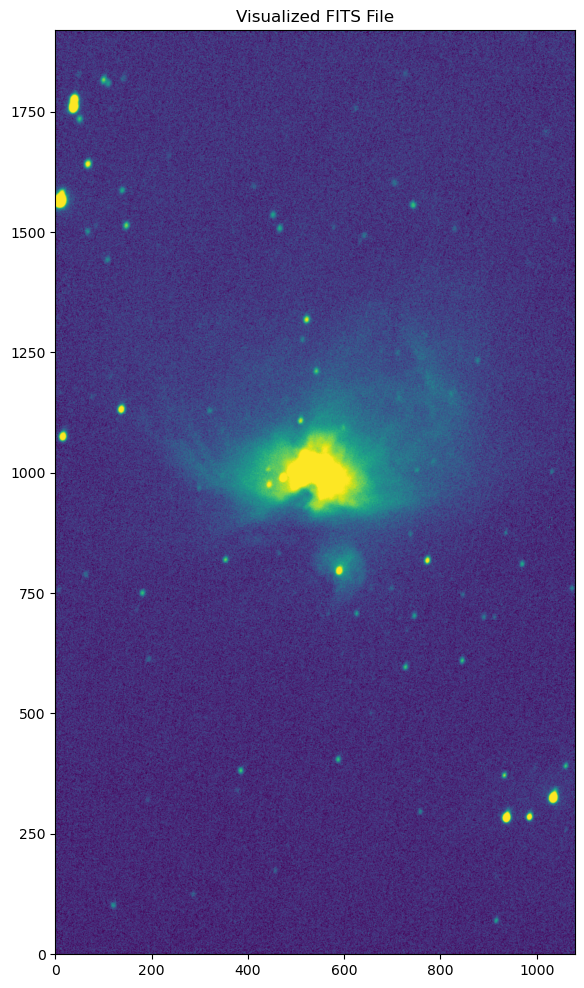

In [25]:
import matplotlib.pylab as plt
from astropy.visualization import simple_norm
plt.figure(figsize = [12,12])
norm = simple_norm(data, 'asinh', percent = 99) #Notice how I use 'data' here. Another option is to use hdul['SCI'].data directly
# 'asinh' is the scale i use to

plt.imshow(data, origin = 'lower', norm = norm, cmap = 'viridis')
plt.title('Visualized FITS File')
#Take note of the scale for x and y axis and compare to data.shape

### I am going to do a background subtraction which will let me get a better look at each of these individual sources
##### For my data specifically I have processed the data more because I'm working with Webb data which creates diffraction spikes for PSF's so I'm going to upload a new file that did a decent job at getting rid of these spikes.

In [22]:
# Hashtag this out when working with your own data
hdul = fits.open('/Users/sshapiro/Desktop/jw01160-o022_f356w_gaia_pipeline_CLEAN_nlambad_521_V3_i2d.fits')
data = hdul['SCI'].data

In [24]:
from astropy.stats import SigmaClip
from photutils.background import Background2D, MedianBackground
sigma_clip = SigmaClip(sigma=4.5)
bkg_estimator = MedianBackground()
bkg = Background2D(data, (200, 200), filter_size=(3, 3),
                   sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)
im_subbk = (data-bkg.background)

2025-07-14 14:27:28,728 - stpipe - WARNING - Input data contains invalid values (NaNs or infs), which were automatically masked.


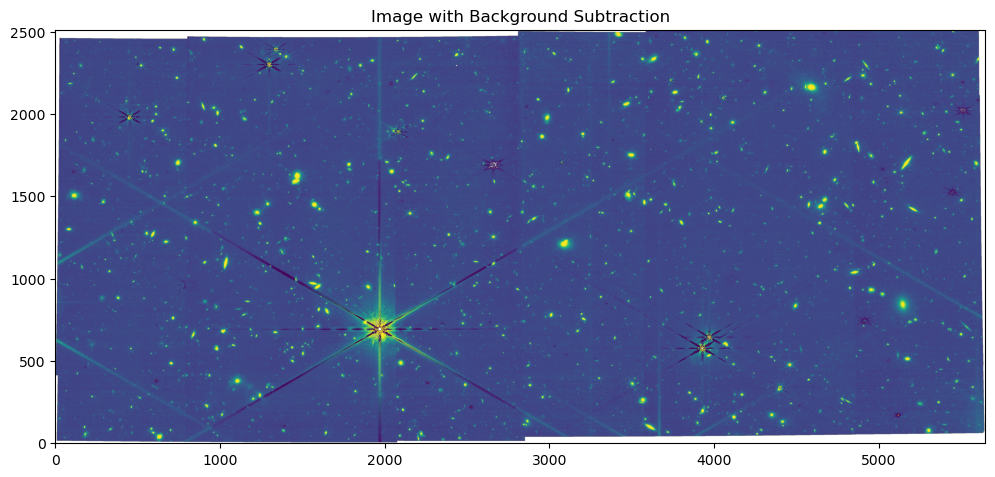

In [26]:
def plot_imsubbk(title = "Image with Background Subtraction"):
    norm = simple_norm(im_subbk, 'asinh', percent=99.5)
    plt.figure(figsize=(12,12))
    plt.imshow(im_subbk, origin = 'lower', norm = norm, cmap = 'viridis')
    plt.title(title)
    plt.show()

plot_imsubbk()

In [42]:
from astropy.wcs import WCS
## We want to sync our file up with the WCS.. this will come in handy later
wcs = WCS(hdul['SCI'].header)

### The next step in my evil plan is to isolate each source using image segmentation and deblend any sources that tried to pass off as just one.

In [27]:
#Package Installation
from astropy.convolution import convolve
from photutils.segmentation import make_2dgaussian_kernel

from photutils.segmentation import detect_sources

from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize

from photutils.segmentation import deblend_sources
from photutils.segmentation import SourceCatalog
from photutils.utils import calc_total_error
from photutils.segmentation import SourceFinder

from photutils.segmentation import detect_threshold  

from astropy import units as u


In [30]:
kernel = make_2dgaussian_kernel(3.0, size=5)  # FWHM = 3.0
convolved_data = convolve(im_subbk, kernel)
threshold = detect_threshold(convolved_data, nsigma=10)
segment_map =detect_sources(convolved_data, threshold, npixels=20)
segm_deblend = deblend_sources(convolved_data, segment_map, 
                npixels=10, nlevels=32, contrast=0.001, progress_bar=False)

2025-07-14 14:33:48,465 - stpipe - WARNING - nan_treatment='interpolate', however, NaN values detected post convolution. A contiguous region of NaN values, larger than the kernel size, are present in the input array. Increase the kernel size to avoid this.
2025-07-14 14:33:48,511 - stpipe - WARNING - Input data contains invalid values (NaNs or infs), which were automatically clipped.
2025-07-14 14:33:53,727 - stpipe - WARNING - The deblending mode of one or more source labels from the input segmentation image was changed from "exponential" to "linear". See the "info" attribute for the list of affected input labels.


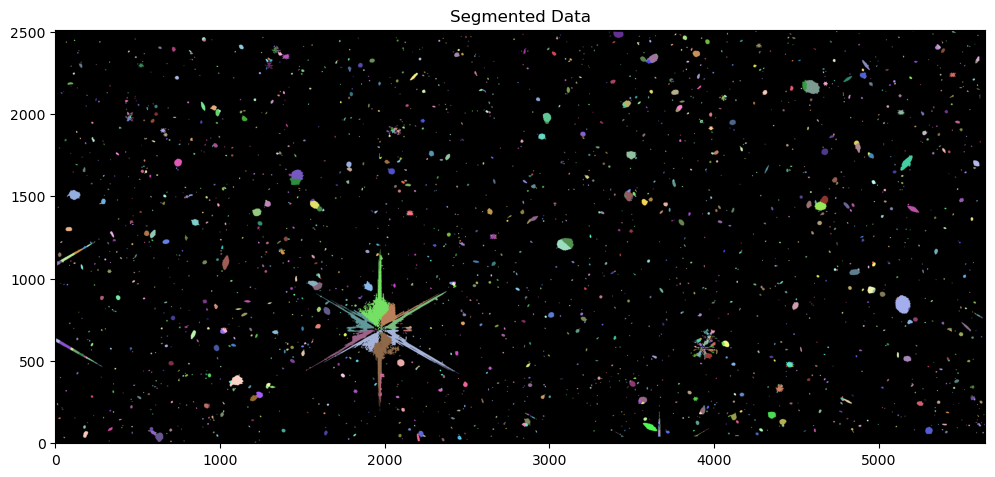

In [32]:
def plot_segmentation_map(title = "Segmented Data"):
    plt.figure(figsize=(12,12))
    plt.imshow(segm_deblend, origin = 'lower', cmap = segm_deblend.cmap)
    plt.title(title)
    plt.show()

plot_segmentation_map()

In [43]:
#Create a catalog of these sources
cat = SourceCatalog(im_subbk, segm_deblend, convolved_data=convolved_data, wcs=wcs)
tbl = cat.to_table()
tbl['xcentroid'].info.format = '.2f'  # optional format
tbl['ycentroid'].info.format = '.2f'
tbl['kron_flux'].info.format = '.2f'

#[print(f"{i}: {ap.to_sky(wcs_list[2])}") for i, ap in enumerate(cat.kron_aperture)]


In [55]:
from photutils.aperture import aperture_photometry
cat_list=[]

band_fluxes= [aperture_photometry(im_subbk, cat.kron_aperture[i].to_sky(wcs), wcs=wcs)['aperture_sum'].value[0] for i in range(len(cat))]
    
cat_list.append(band_fluxes)


### Optional: Filter through the sources to make sure they're all real

In [78]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Button, TextBox
from astropy.nddata import Cutout2D
from astropy.visualization import simple_norm
import astropy.units as u
%matplotlib widget

def yes_no_source_selection():
    class CatalogReviewer:
        def __init__(self, cat):
            self.cat = cat
            self.index = 0
            self.status_file = "catalog_review_status.npy"

            if os.path.exists(self.status_file):
                self.status = np.load(self.status_file).tolist()
            else:
                self.status = [0] * len(cat)

            self.fig, self.axs = plt.subplots(1, 2, figsize=(10, 5))  # Only two panels now
            plt.subplots_adjust(top=.75, bottom=0.2, hspace=.25, wspace=.3)

            # Buttons
            axyes = plt.axes([0.3, 0.05, 0.1, 0.075])
            axno = plt.axes([0.6, 0.05, 0.1, 0.075])
            ax_go = plt.axes([0.45, 0.05, 0.1, 0.075])
            self.byes = Button(axyes, 'Yes')
            self.bno = Button(axno, 'No')
            self.textbox = TextBox(ax_go, 'Go to')
            self.byes.on_clicked(self.yes)
            self.bno.on_clicked(self.no)
            self.textbox.on_submit(self.go_to)
            axmaybe = plt.axes([0.75, 0.05, 0.1, 0.075])
            self.bmaybe = Button(axmaybe, 'Maybe')
            self.bmaybe.on_clicked(self.maybe)
            axskip = plt.axes([0.05, 0.05, 0.2, 0.075])
            self.bskip = Button(axskip, 'Next Undecided')
            self.bskip.on_clicked(self.skip)

            self.text_ax = self.fig.add_axes([0.01, 0.85, .23, .12])
            self.text_ax.axis('off')
            self.text_box = self.text_ax.text(0, 1, '', ha='left', va='top', fontsize=9,
                                              color='black', wrap=True, family='monospace')

            self.display()
            plt.show()

        def save_status(self):
            np.save(self.status_file, np.array(self.status))

        def display(self):
            i = self.index
            ap_sky = self.cat.kron_aperture[i].to_sky(wcs)
            sky_pos = ap_sky.positions
            cutout_size = 6 * u.arcsec

            cutout_img = Cutout2D(im_subbk, sky_pos, cutout_size, wcs=wcs)
            cutout_segm = Cutout2D(segm_deblend, sky_pos, cutout_size, wcs=wcs)
            ap_pix = ap_sky.to_pixel(cutout_img.wcs)

            norm_im = simple_norm(cutout_img.data, 'asinh', percent=99.5)
            norm_seg = simple_norm(cutout_segm.data, 'asinh', percent=99.5)

            for ax in self.axs:
                ax.clear()

            # Regular image
            self.axs[0].imshow(cutout_img.data, origin='lower', cmap='viridis', norm=norm_im)
            ap_pix.plot(ax=self.axs[0], color='lime', lw=1)
            self.axs[0].set_title("Original Image")

            # Deblended image
            self.axs[1].imshow(cutout_segm.data, origin='lower', cmap='nipy_spectral', norm=norm_seg)
            ap_pix.plot(ax=self.axs[1], color='lime', lw=1)
            self.axs[1].set_title("Deblended Segmentation")

            status_str = {1: "✔ Accepted", -1: "✘ Rejected", 0: "⏳ Undecided"}
            self.fig.suptitle(f"Source {i} — {status_str[self.status[i]]}", fontsize=14, fontweight='bold', color='hotpink')
            self.fig.canvas.draw_idle()

            ap_text = (
                f"Aperture: SkyEllipticalAperture\n"
                f"positions: <SkyCoord (ICRS): (ra, dec) in deg\n"
                f"    ({ap_sky.positions.ra.deg:.8f}, {ap_sky.positions.dec.deg:.8f})>\n"
                f"a: {ap_sky.a.to_value(u.arcsec):.17f} arcsec\n"
                f"b: {ap_sky.b.to_value(u.arcsec):.17f} arcsec\n"
                f"theta: {ap_sky.theta.to_value(u.rad):.15f} rad"
            )
            self.text_box.set_text(ap_text)
            self.text_ax.figure.canvas.draw_idle()

        def yes(self, event):
            self.status[self.index] = 1
            self.save_status()
            self.next()

        def no(self, event):
            self.status[self.index] = -1
            self.save_status()
            self.next()

        def maybe(self, event):
            self.status[self.index] = 0
            self.save_status()
            self.next()

        def skip(self, event):
            for i in range(self.index + 1, len(self.cat)):
                if self.status[i] == 0:
                    self.index = i
                    self.display()
                    return
            print("No more undecided items.")

        def next(self):
            if self.index < len(self.cat) - 1:
                self.index += 1
                self.display()
            else:
                print("Done reviewing!")
                self.finish()
                plt.close(self.fig)

        def go_to(self, text):
            try:
                idx = int(text)
                if 0 <= idx < len(self.cat):
                    self.index = idx
                    self.display()
            except ValueError:
                print("Invalid input. Please enter a number.")

        def finish(self):
            accepted_cat = self.cat[np.array(self.status) == 1]
            accepted_cat.write('accepted_catalog.txt', format='ascii', overwrite=True)
            print("Accepted catalog saved.")

    viewer = CatalogReviewer(cat)


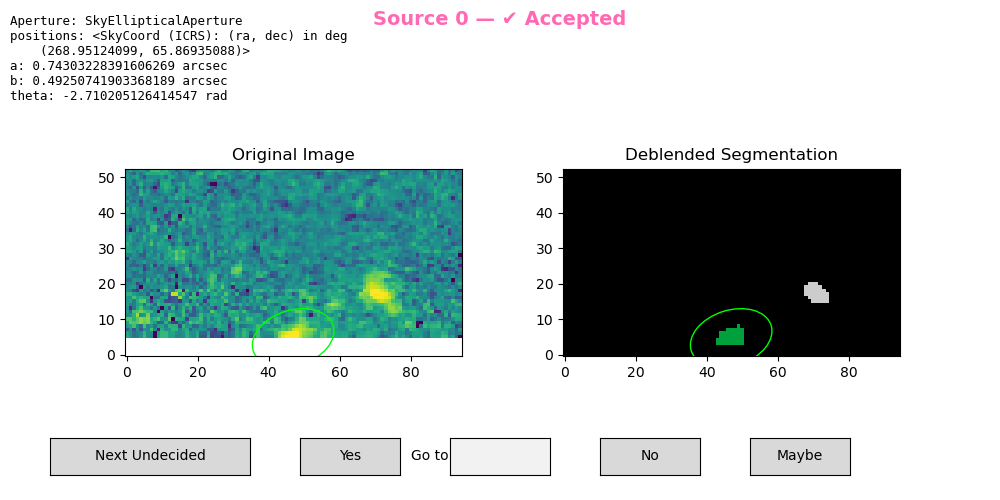

In [102]:
yes_no_source_selection() 

In [92]:
from astropy.table import Table
from photutils.segmentation import SourceCatalog, SegmentationImage

# Step 1: Load your table
acc_cat = Table.read("acc_cat_table.txt", format="ascii.fixed_width")  # or ascii

# Step 2: Get labels
labels = acc_cat['label']  # must match your segmentation map's IDs

# Step 3: Mask segmentation map to keep only accepted labels
mask = np.isin(segm_deblend.data, labels)
filtered_data = np.where(mask, segm_deblend.data, 0)
segm_filtered = SegmentationImage(filtered_data)

# Step 4: Rebuild the catalog
acc_cat = SourceCatalog(data=im_subbk, segment_img=segm_filtered, wcs=wcs)


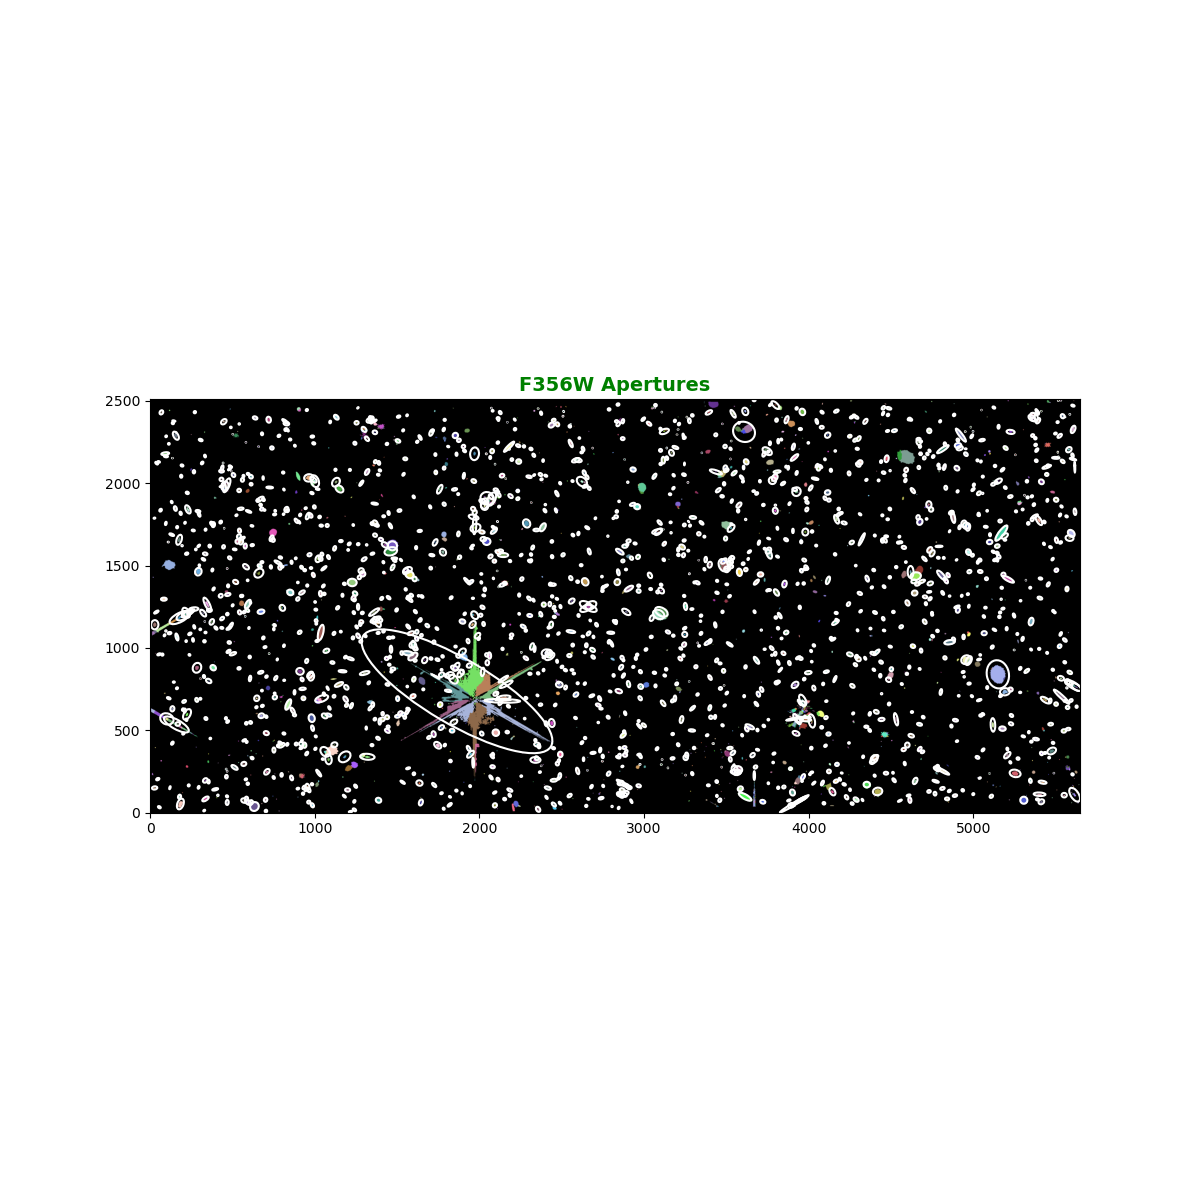

In [93]:
#Let's look at the image now with apertures around accepted sources
def segmentation_kron():
    plt.figure(figsize = [12, 12])
    plt.imshow(segm_deblend, origin = 'lower', cmap=segm_deblend.cmap)
    plt.title("F356W Apertures", fontsize=14, fontweight='bold', color='Green')
    acc_cat.plot_kron_apertures(color = 'white', lw=1.5)

segmentation_kron()


### There are a few different roads to go down now
##### 
#####
#####
#####